# 02 — Coast-Down Segment Extraction & ODE Fit

Extract coast-down segments from Canada 2026 sessions (FP1, Sprint, Race),
fit α and β per segment, and report the pooled aerodynamic composite (CdA + Crr·ClA).

In [1]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from src.segments import extract_coastdown_segments
from src.ode_fit import v_model, fit_segment, fit_segments_pooled, FitResult
from src.aero_params import air_density, car_mass

fastf1.Cache.enable_cache('../cache')

## Driver survey — FP1, Sprint, Race

Canada 2026 is a Sprint weekend: only one practice session (FP1).
We extend the survey to include Sprint and Race to ensure enough coast-down
segments for a reliable pooled fit.

In [2]:
import os, pickle

SURVEY_CACHE = '../results/survey_cache.pkl'
SURVEY_CIRCUITS = ['Canada']
SURVEY_SESSIONS = ['FP1', 'Sprint', 'Race']

# Canada's straights are shorter than Monza — coast-downs drop ~10–15 m/s, not 25 m/s.
# Lower min_speed_drop accordingly; keep min_speed_kmh at 120 to exclude slow corners.
MIN_SPEED_DROP = 10.0  # m/s (Monza default is 25.0)

if os.path.exists(SURVEY_CACHE):
    with open(SURVEY_CACHE, 'rb') as f:
        survey_data = pickle.load(f)
    survey_df = survey_data['survey_df']
    totals     = survey_data['totals']
    print('Loaded survey from cache.')
else:
    survey_rows = []

    for circuit in SURVEY_CIRCUITS:
        for session_name in SURVEY_SESSIONS:
            try:
                sess = fastf1.get_session(2026, circuit, session_name)
                sess.load(telemetry=True, weather=True)
            except Exception as e:
                print(f'Could not load {circuit} {session_name}: {e}')
                continue

            rho_s = air_density(sess.weather_data['AirTemp'].mean(),
                                sess.weather_data['Pressure'].mean())

            for driver in sess.drivers:
                try:
                    laps = sess.laps.pick_drivers(driver)
                    laps = laps[laps['LapNumber'] > 1]
                except Exception:
                    continue

                n_segs = 0
                for _, lap in laps.iterrows():
                    lap_num = int(lap['LapNumber'])
                    m = car_mass(lap_num)
                    try:
                        tel = lap.get_telemetry()
                    except Exception:
                        continue
                    segs = extract_coastdown_segments(
                        tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
                    )
                    for seg in segs:
                        result = fit_segment(seg, m, rho_s, False, lap_num,
                                             min_speed_drop=MIN_SPEED_DROP)
                        if result is not None and result.r2 >= 0.90:
                            n_segs += 1

                if n_segs > 0:
                    survey_rows.append({
                        'circuit': circuit,
                        'session': session_name,
                        'driver': driver,
                        'n_segments': n_segs,
                    })

    survey_df = pd.DataFrame(survey_rows).sort_values('n_segments', ascending=False).reset_index(drop=True)
    totals = (
        survey_df.groupby(['circuit', 'driver'])
        .agg(total_segments=('n_segments', 'sum'))
        .sort_values('total_segments', ascending=False)
        .reset_index()
    )

    with open(SURVEY_CACHE, 'wb') as f:
        pickle.dump({'survey_df': survey_df, 'totals': totals}, f)
    print('Survey complete. Results cached.')

print(survey_df.to_string(index=False))
print('\n--- Totals across all sessions ---')
print(totals.to_string(index=False))

best_circuit = totals.iloc[0]['circuit']
best_driver  = totals.iloc[0]['driver']
print(f'\nSelected: {best_circuit} — driver {best_driver}  '
      f'({int(totals.iloc[0]["total_segments"])} segments)')

Loaded survey from cache.
circuit session driver  n_segments
 Canada     FP1     14           2
 Canada     FP1      1           1
 Canada     FP1      6           1
 Canada     FP1     16           1
 Canada     FP1     18           1

--- Totals across all sessions ---
circuit driver  total_segments
 Canada     14               2
 Canada      1               1
 Canada     16               1
 Canada     18               1
 Canada      6               1

Selected: Canada — driver 14  (2 segments)


## Load session and select driver

In [3]:
print(f'Circuit: {best_circuit}')
print(f'Driver:  {best_driver}')
print('Pooling FP1, Sprint, Race')

Circuit: Canada
Driver:  14
Pooling FP1, Sprint, Race


## Extract coast-down segments across all laps

In [4]:
all_results: list[FitResult] = []
all_segments_for_plot = []
rho_values = []

BETA_FIXED = 120.0  # N

for session_name in ['FP1', 'Sprint', 'Race']:
    try:
        session = fastf1.get_session(2026, best_circuit, session_name)
        session.load(telemetry=True, weather=True)
    except Exception as e:
        print(f'Skipping {best_circuit} {session_name}: {e}')
        continue

    rho_s = air_density(session.weather_data['AirTemp'].mean(),
                        session.weather_data['Pressure'].mean())
    rho_values.append(rho_s)

    laps = session.laps.pick_drivers(best_driver)
    laps_filtered = laps[laps['LapNumber'] > 1].copy()
    n_before = len(all_results)

    for _, lap in laps_filtered.iterrows():
        lap_num = int(lap['LapNumber'])
        m = car_mass(lap_num)
        try:
            tel = lap.get_telemetry()
        except Exception:
            continue

        segs = extract_coastdown_segments(
            tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
        )
        for seg in segs:
            result = fit_segment(seg, m, rho_s, False, lap_num,
                                 beta_fixed=BETA_FIXED,
                                 min_speed_drop=MIN_SPEED_DROP)
            if result is not None and result.r2 >= 0.90:
                all_results.append(result)
                all_segments_for_plot.append((seg, result))

    print(f'{session_name}: {len(all_results) - n_before} segments')

rho = float(np.mean(rho_values))
print(f'\nTotal valid segments: {len(all_results)}')
print(f'min_speed_drop = {MIN_SPEED_DROP} m/s  (lowered from default 25.0 for Canada)')
print(f'Mean air density: {rho:.4f} kg/m³')
print(f'β fixed at: {BETA_FIXED} N  (Crr = {BETA_FIXED/(900*9.81):.4f})')

core           INFO 	Loading data for Canadian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Canadian Grand Prix - Sprint [v3.8.3]
req            INFO 

FP1: 6 segments


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '1', '12', '81', '16', '44', '3', '41', '43', '55', '30', '5', '31', '11', '27', '18', '77', '87', '23', '10', '6', '14']
core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Sprint: 0 segments


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 41)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '3', '16', '6', '43', '30', '10', '55', '87', '81', '27', '5', '31', '18', '77', '11', '1', '63', '14', '23', '41']


Race: 0 segments

Total valid segments: 6
min_speed_drop = 10.0 m/s  (lowered from default 25.0 for Canada)
Mean air density: 1.2362 kg/m³
β fixed at: 120.0 N  (Crr = 0.0136)


## Visualise fit quality — sample of segments

## Residual analysis — model specification check

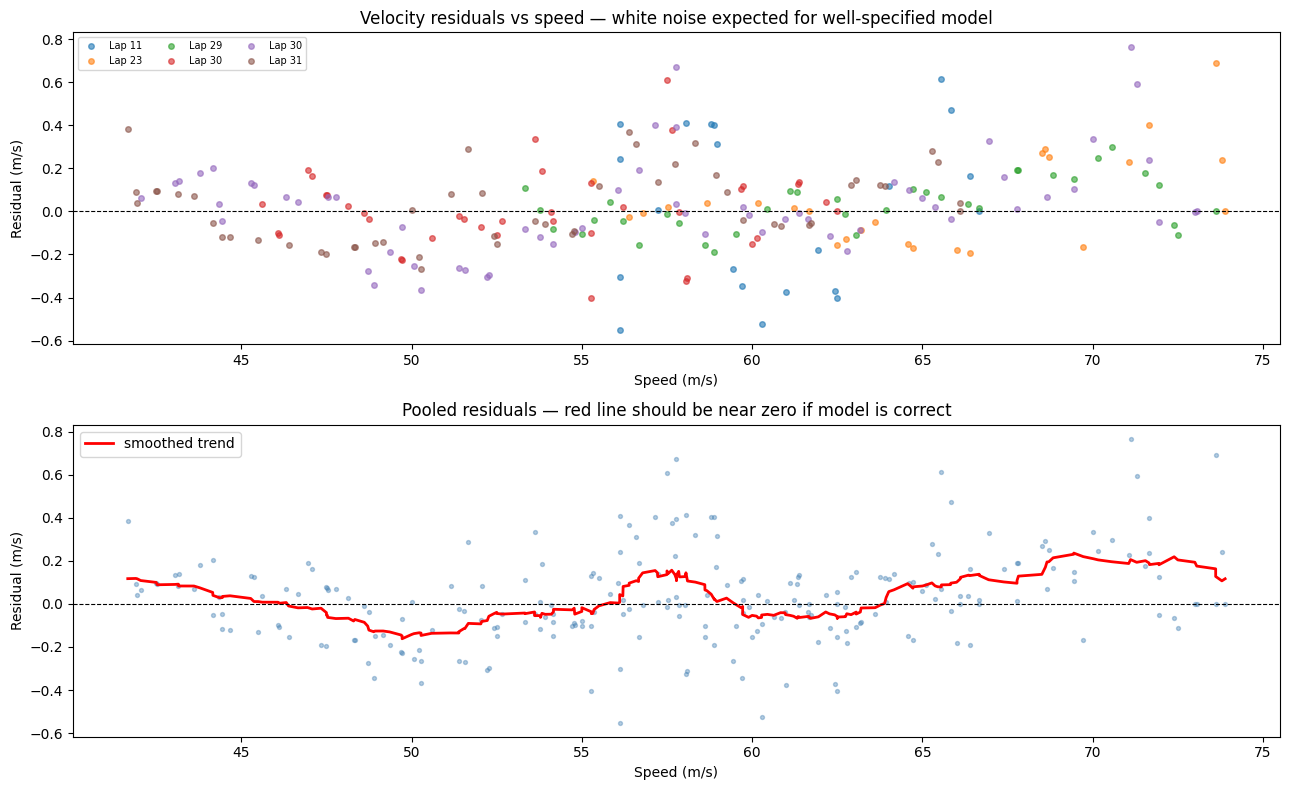


Durbin-Watson statistics per segment (2.0 = no autocorrelation):
  Lap 11: DW = 0.72  ⚠ autocorrelation
  Lap 23: DW = 0.83  ⚠ autocorrelation
  Lap 29: DW = 0.50  ⚠ autocorrelation
  Lap 30: DW = 1.23  ⚠ autocorrelation
  Lap 30: DW = 0.47  ⚠ autocorrelation
  Lap 31: DW = 0.54  ⚠ autocorrelation

Mean DW: 0.71


In [5]:
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

all_speeds, all_resids = [], []
dw_stats = []

for seg, fit in all_segments_for_plot:
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    v_pred = v_model(t, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)
    residuals = v_meas - v_pred

    axes[0].plot(v_meas, residuals, 'o', ms=4, alpha=0.6,
                 label=f'Lap {fit.lap_number}')
    all_speeds.extend(v_meas.tolist())
    all_resids.extend(residuals.tolist())
    dw_stats.append(durbin_watson(residuals))

axes[0].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Speed (m/s)')
axes[0].set_ylabel('Residual (m/s)')
axes[0].set_title('Velocity residuals vs speed — white noise expected for well-specified model')
axes[0].legend(fontsize=7, ncol=3)

# Pooled residuals with LOWESS trend to detect systematic shape
from scipy.ndimage import uniform_filter1d
idx = np.argsort(all_speeds)
v_sorted = np.array(all_speeds)[idx]
r_sorted = np.array(all_resids)[idx]
r_smooth = uniform_filter1d(r_sorted, size=max(3, len(r_sorted)//10))
axes[1].scatter(v_sorted, r_sorted, s=8, alpha=0.4, color='steelblue')
axes[1].plot(v_sorted, r_smooth, 'r-', lw=2, label='smoothed trend')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Speed (m/s)')
axes[1].set_ylabel('Residual (m/s)')
axes[1].set_title('Pooled residuals — red line should be near zero if model is correct')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/02_residuals.png', dpi=150)
plt.show()

print(f'\nDurbin-Watson statistics per segment (2.0 = no autocorrelation):')
for i, (_, fit) in enumerate(all_segments_for_plot):
    flag = '✓' if 1.5 <= dw_stats[i] <= 2.5 else '⚠ autocorrelation'
    print(f'  Lap {fit.lap_number}: DW = {dw_stats[i]:.2f}  {flag}')
print(f'\nMean DW: {np.mean(dw_stats):.2f}')

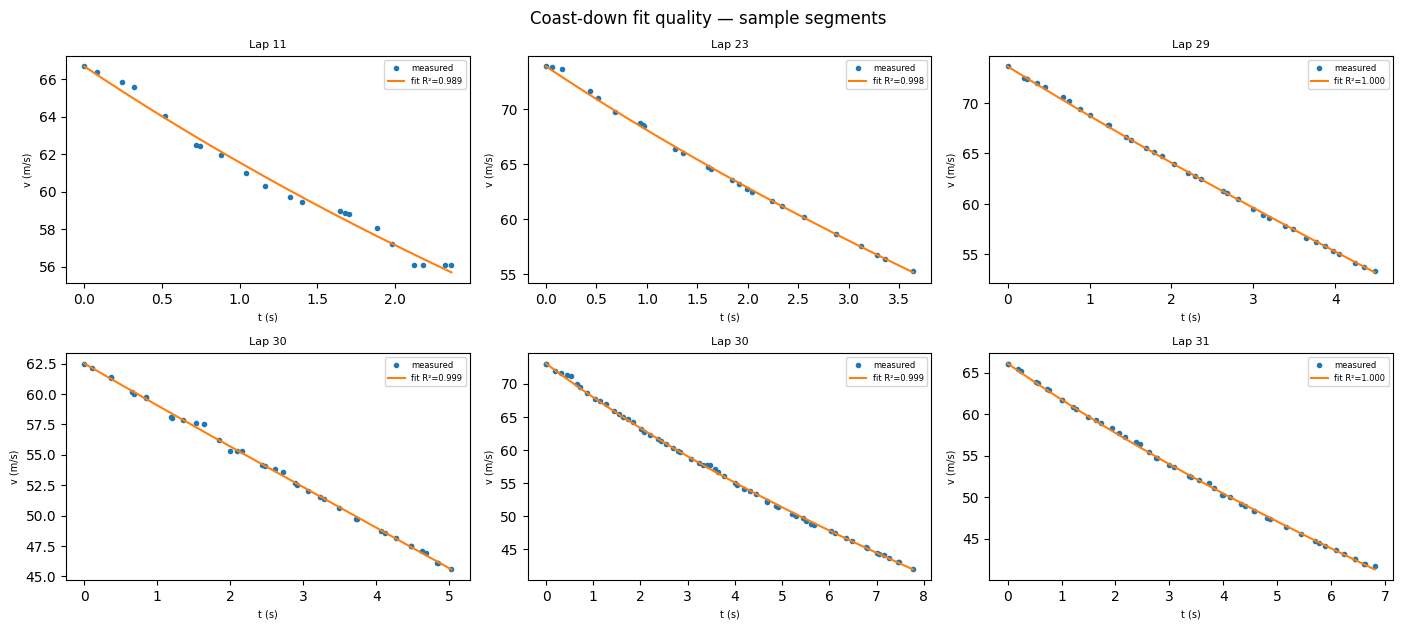

In [6]:
n_plot = min(9, len(all_segments_for_plot))
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (seg, fit) in enumerate(all_segments_for_plot[:n_plot]):
    ax = axes[idx]
    t = seg['t'].values - seg['t'].values[0]
    v_meas = seg['Speed'].values / 3.6
    t_dense = np.linspace(0, t[-1], 200)
    v_pred = v_model(t_dense, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)
    ax.plot(t, v_meas, 'o', ms=3, label='measured')
    ax.plot(t_dense, v_pred, '-', label=f'fit R²={fit.r2:.3f}')
    ax.set_title(f'Lap {fit.lap_number}', fontsize=8)
    ax.set_xlabel('t (s)', fontsize=7)
    ax.set_ylabel('v (m/s)', fontsize=7)
    ax.legend(fontsize=6)

for idx in range(n_plot, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Coast-down fit quality — sample segments')
plt.tight_layout()
plt.savefig('../results/figures/02_fit_quality.png', dpi=150)
plt.show()

## α / β scatter

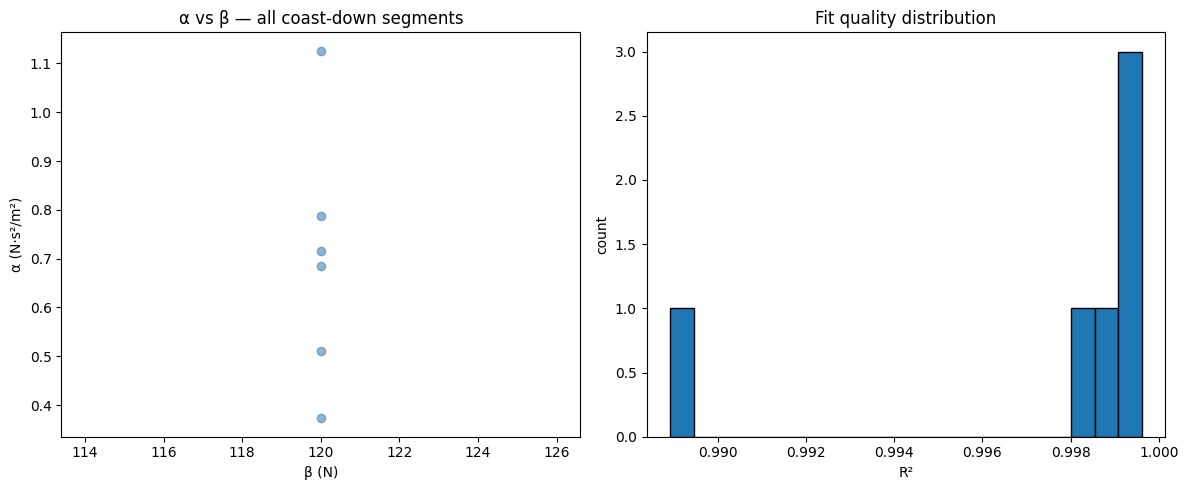

Median α: 0.7009  (expected ~0.5–1.0 N·s²/m²)
Median β: 120.0 N
Median P_mgu: 72.8 kW


In [7]:
alphas = [r.alpha for r in all_results]
betas  = [r.beta  for r in all_results]
p_mgus = [r.P_mgu for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(betas, alphas, alpha=0.6, color='steelblue')
ax.set_xlabel('β (N)')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs β — all coast-down segments')

ax = axes[1]
ax.hist([r.r2 for r in all_results], bins=20, edgecolor='black')
ax.set_xlabel('R²')
ax.set_ylabel('count')
ax.set_title('Fit quality distribution')

plt.tight_layout()
plt.savefig('../results/figures/02_alpha_beta_scatter.png', dpi=150)
plt.show()

print(f'Median α: {np.median(alphas):.4f}  (expected ~0.5–1.0 N·s²/m²)')
print(f'Median β: {np.median(betas):.1f} N')
print(f'Median P_mgu: {np.median(p_mgus)/1000:.1f} kW')

## α vs lap number — fuel load sensitivity

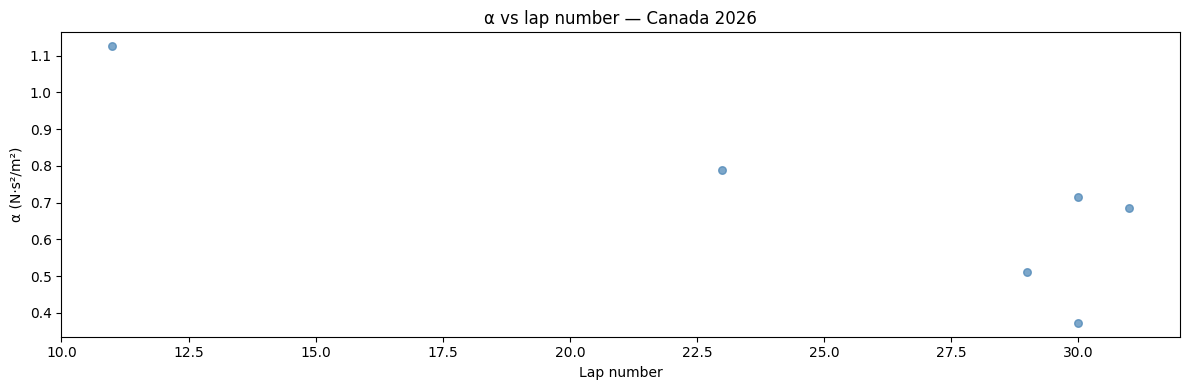

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter([r.lap_number for r in all_results],
           [r.alpha      for r in all_results],
           alpha=0.7, s=30, color='steelblue')
ax.set_xlabel('Lap number')
ax.set_ylabel('α (N·s²/m²)')
ax.set_title('α vs lap number — Canada 2026')
plt.tight_layout()
plt.savefig('../results/figures/02_alpha_vs_lap.png', dpi=150)
plt.show()

## Pooled fit — shared α across all segments

In [9]:
segs_pool = [seg for seg, _ in all_segments_for_plot]
m_pool    = [r.m          for _, r in all_segments_for_plot]
lap_pool  = [r.lap_number for _, r in all_segments_for_plot]
mode_pool = [r.straight_mode for _, r in all_segments_for_plot]

print(f'Running pooled fit on {len(segs_pool)} segments (β fixed = {BETA_FIXED} N)...')
pooled_results = fit_segments_pooled(
    segs_pool, m_pool, mode_pool, lap_pool,
    seed_results=all_results,
    beta_fixed=BETA_FIXED,
)

if pooled_results is None:
    print('Pooled fit failed — keeping per-segment results.')
    alpha_p, alpha_std_p = float('nan'), float('nan')
else:
    alpha_p     = pooled_results[0].alpha
    alpha_std_p = pooled_results[0].alpha_std
    p_mgus_p    = [r.P_mgu / 1000 for r in pooled_results]
    composite   = 2.0 * alpha_p / rho

    print(f'\n=== Pooled fit results ===')
    print(f'α  = {alpha_p:.4f} ± {alpha_std_p:.4f}  N·s²/m²')
    print(f'β  = {BETA_FIXED:.1f} N (fixed)  →  Crr = {BETA_FIXED/(900*9.81):.4f}')
    print(f'Composite 2α/ρ = {composite:.3f} m²  (CdA + Crr·ClA)')
    print(f'P_mgu range (kW): {min(p_mgus_p):.1f} – {max(p_mgus_p):.1f}')

    all_results = pooled_results

Running pooled fit on 6 segments (β fixed = 120.0 N)...

=== Pooled fit results ===
α  = 0.6816 ± 0.0083  N·s²/m²
β  = 120.0 N (fixed)  →  Crr = 0.0136
Composite 2α/ρ = 1.103 m²  (CdA + Crr·ClA)
P_mgu range (kW): 43.4 – 113.5


## Miami cross-validation

Repeat the coast-down fit on Miami 2026 data (also a Sprint weekend: FP1 + Sprint)
and compare α to Canada. The ratio reflects relative aerodynamic drag between setups.

In [ ]:
if not np.isfinite(alpha_p):
    print('Canada pooled fit failed — skipping Miami validation.')
else:
    miami_results = []
    for session_name in ['FP1', 'Sprint']:
        try:
            sess = fastf1.get_session(2026, 'Miami', session_name)
            sess.load(telemetry=True, weather=True)
        except Exception as e:
            print(f'  Skipping Miami {session_name}: {e}')
            continue

        rho_miami = air_density(sess.weather_data['AirTemp'].mean(),
                                sess.weather_data['Pressure'].mean())

        for driver in sess.drivers:
            try:
                laps_m = sess.laps.pick_drivers(driver)
                laps_m = laps_m[laps_m['LapNumber'] > 1]
            except Exception:
                continue
            for _, lap in laps_m.iterrows():
                lap_num = int(lap['LapNumber'])
                m = car_mass(lap_num)
                try:
                    tel = lap.get_telemetry()
                except Exception:
                    continue
                segs = extract_coastdown_segments(
                    tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0,
                )
                for seg in segs:
                    r = fit_segment(seg, m, rho_miami, False, lap_num,
                                    beta_fixed=BETA_FIXED,
                                    min_speed_drop=MIN_SPEED_DROP)
                    if r is not None and r.r2 >= 0.90:
                        miami_results.append(r)

    if miami_results:
        alpha_miami = np.median([r.alpha for r in miami_results])
        ratio = alpha_miami / alpha_p
        print(f'Miami segments: {len(miami_results)}')
        print(f'Miami median α: {alpha_miami:.4f}  Canada pooled α: {alpha_p:.4f}')
        print(f'Ratio Miami/Canada: {ratio:.2f}  (expected 1.0–1.3; Miami typically higher-downforce setup)')
    else:
        print('No valid Miami segments found after quality filter.')

core           INFO 	Loading data for Miami Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '81'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']


In [ ]:
import pickle
with open('../results/fit_results.pkl', 'wb') as f:
    pickle.dump({'results': all_results, 'rho': rho, 'driver': best_driver}, f)
print('Saved fit_results.pkl')